# Stage 06 — HELOC LIME Explanations

This notebook applies LIME to the frozen HELOC model and fixed 20-case cohort. LIME operates on the 22 original raw features while every perturbed row is routed through the frozen preprocessor.

## 1. Frozen transformer compatibility

The Stage 03 transformer definition is repeated unchanged so the saved preprocessor can be loaded. It is used only for transformation.

In [1]:
from pathlib import Path
import hashlib
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.utils.validation import check_is_fitted

pd.set_option("display.max_columns", None); pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

class HELOCSpecialValuePreprocessor(BaseEstimator, TransformerMixin):
    """Median-impute HELOC measurements and append training-observed special-code indicators."""
    def __init__(self, feature_names, special_codes=(-7, -8, -9)):
        self.feature_names = feature_names; self.special_codes = special_codes
    def fit(self, X, y=None):
        frame = self._frame(X); self.feature_names_in_ = np.asarray(self.feature_names, dtype=object)
        self.indicator_pairs_ = [(feature, int(code)) for feature in self.feature_names for code in self.special_codes if frame[feature].eq(code).any()]
        numeric = frame[self.feature_names].mask(frame[self.feature_names].isin(self.special_codes))
        self.imputer_ = SimpleImputer(strategy="median", keep_empty_features=True); self.imputer_.fit(numeric); self.n_features_in_ = len(self.feature_names); return self
    def transform(self, X):
        check_is_fitted(self, ["imputer_", "indicator_pairs_"]); frame = self._frame(X)
        numeric = frame[self.feature_names].mask(frame[self.feature_names].isin(self.special_codes)); imputed = self.imputer_.transform(numeric)
        indicators = np.column_stack([frame[f].eq(c).astype(np.int8).to_numpy() for f,c in self.indicator_pairs_]) if self.indicator_pairs_ else np.empty((len(frame),0),dtype=np.int8)
        return np.hstack([imputed, indicators]).astype(float, copy=False)
    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["imputer_", "indicator_pairs_"])
        return np.asarray([f"{f}__numeric_imputed" for f in self.feature_names]+[f"{f}__is_minus{abs(c)}" for f,c in self.indicator_pairs_],dtype=object)
    def _frame(self, X):
        if isinstance(X,pd.DataFrame):
            missing=set(self.feature_names)-set(X.columns)
            if missing: raise ValueError(f"Missing required features: {sorted(missing)}")
            return X.loc[:,self.feature_names].copy()
        return pd.DataFrame(X,columns=self.feature_names)

## 2. Exact frozen reconstruction

The immutable snapshot and saved indexes reconstruct both partitions. Model metrics are reproduced before explanation.

In [2]:
PROJECT_ROOT=Path.cwd().resolve()
if PROJECT_ROOT.name=="heloc": PROJECT_ROOT=PROJECT_ROOT.parents[2]
elif PROJECT_ROOT.name=="ml": PROJECT_ROOT=PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name=="backend": PROJECT_ROOT=PROJECT_ROOT.parent
RAW_PATH=PROJECT_ROOT/"backend"/"data"/"heloc"/"raw"/"heloc_raw.csv"; ARTIFACT_DIR=PROJECT_ROOT/"backend"/"artifacts"/"heloc"; PLOT_DIR=ARTIFACT_DIR/"plots"
EXPECTED_HASH="786b7e1885cf508ef66a968aae65a72bfde198d06d7666ac582958705b092570"; TARGET="is_at_risk"; THRESHOLD=.50; SPECIAL_CODES=(-7,-8,-9)
NUM_SAMPLES=5000; NUM_FEATURES=5; RANDOM_STATE=42

files={"selection":"selected_features.json","train":"train_indices.csv","test":"test_indices.csv","preprocessor":"preprocessor.joblib",
"preprocessing_metadata":"preprocessing_metadata.json","mapping":"transformed_feature_mapping.csv","model":"xgboost_credit_model.joblib",
"model_metadata":"model_metadata.json","cases":"xai_evaluation_cases.csv","shap_top":"shap_top_factors.csv",
"shap_stability":"shap_preliminary_stability.csv","shap_faithfulness":"shap_preliminary_faithfulness.csv"}
paths={k:ARTIFACT_DIR/v for k,v in files.items()}
for path in paths.values():
    if not path.exists(): raise FileNotFoundError(path)
assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()==EXPECTED_HASH

raw_df=pd.read_csv(RAW_PATH); selection=json.loads(paths["selection"].read_text(encoding="utf-8")); selected_features=selection["selected_features"]
train_indices=pd.read_csv(paths["train"])["row_index"].astype(int); test_indices=pd.read_csv(paths["test"])["row_index"].astype(int)
model_metadata=json.loads(paths["model_metadata"].read_text(encoding="utf-8")); transformed_mapping=pd.read_csv(paths["mapping"])
preprocessor=joblib.load(paths["preprocessor"]); model=joblib.load(paths["model"])
X_train_raw=raw_df.loc[train_indices,selected_features].copy(); X_test_raw=raw_df.loc[test_indices,selected_features].copy()
y_train=raw_df.loc[train_indices,TARGET].copy(); y_test=raw_df.loc[test_indices,TARGET].copy()
X_train_processed=preprocessor.transform(X_train_raw); X_test_processed=preprocessor.transform(X_test_raw)
assert X_train_processed.shape==(7896,33) and X_test_processed.shape==(1974,33)
assert np.isfinite(X_train_processed).all() and np.isfinite(X_test_processed).all()

frozen_probabilities=model.predict_proba(X_test_processed)[:,1]; frozen_predictions=(frozen_probabilities>=THRESHOLD).astype(int)
tn,fp,fn,tp=confusion_matrix(y_test,frozen_predictions,labels=[0,1]).ravel()
metrics={"roc_auc":roc_auc_score(y_test,frozen_probabilities),"pr_auc":average_precision_score(y_test,frozen_probabilities),
"accuracy":accuracy_score(y_test,frozen_predictions),"balanced_accuracy":balanced_accuracy_score(y_test,frozen_predictions),
"precision_positive":precision_score(y_test,frozen_predictions),"recall_positive":recall_score(y_test,frozen_predictions),"f1_positive":f1_score(y_test,frozen_predictions),
"true_negative":int(tn),"false_positive":int(fp),"false_negative":int(fn),"true_positive":int(tp)}
metric_differences={k:abs(float(v)-float(model_metadata["final_holdout_metrics"][k])) for k,v in metrics.items()}; assert max(metric_differences.values())<=1e-12
print("Frozen model loaded: True"); print("Exact train rows reconstructed:",len(X_train_raw)); print("Exact test rows reconstructed:",len(X_test_raw)); display(pd.DataFrame([metrics]))

Frozen model loaded: True
Exact train rows reconstructed: 7896
Exact test rows reconstructed: 1974


,roc_auc,pr_auc,accuracy,balanced_accuracy,precision_positive,recall_positive,f1_positive,true_negative,false_positive,false_negative,true_positive
0,0.803561,0.808368,0.73151,0.730163,0.732026,0.763389,0.747378,660,287,243,784


## 3. Fixed cohort and prediction wrapper

The wrapper accepts raw 22-feature arrays and returns both frozen class probabilities. Nearby continuous perturbations are not rounded to special codes.

In [3]:
def lime_predict_proba(rows):
    frame=pd.DataFrame(np.asarray(rows,dtype=float),columns=selected_features)
    return model.predict_proba(preprocessor.transform(frame))

wrapper_probabilities=lime_predict_proba(X_test_raw.to_numpy())[:,1]
wrapper_max_difference=float(np.max(np.abs(wrapper_probabilities-frozen_probabilities))); assert wrapper_max_difference<=1e-12
xai_cases=pd.read_csv(paths["cases"]); assert len(xai_cases)==xai_cases.case_id.nunique()==xai_cases.row_index.nunique()==20
position_lookup={int(idx):pos for pos,idx in enumerate(test_indices)}; case_positions=np.asarray([position_lookup[int(i)] for i in xai_cases.row_index])
assert set(xai_cases.row_index).issubset(set(test_indices)); assert np.array_equal(xai_cases.true_target,y_test.loc[xai_cases.row_index].to_numpy())
assert np.allclose(xai_cases.predicted_probability,frozen_probabilities[case_positions]); assert np.array_equal(xai_cases.predicted_class,(xai_cases.predicted_probability>=THRESHOLD).astype(int))
assert xai_cases.groupby("case_type").size().to_dict()=={"high-confidence positive":5,"borderline positive":5,"high-confidence negative":5,"borderline negative":5}
print("Maximum wrapper probability difference:",wrapper_max_difference); display(xai_cases.groupby("case_type").size().rename("cases").reset_index())

Maximum wrapper probability difference: 0.0


,case_type,cases
0,borderline negative,5
1,borderline positive,5
2,high-confidence negative,5
3,high-confidence positive,5


## 4. LIME configuration and local explanations

The complete 7,896-row training partition is the background. All cases use one fixed configuration and explain class 1, the at-risk output.

In [4]:
display_lookup=transformed_mapping.drop_duplicates("original_feature").set_index("original_feature").display_feature.to_dict()
def make_explainer():
    return LimeTabularExplainer(X_train_raw.to_numpy(dtype=float),feature_names=selected_features,class_names=["not at risk","at risk"],
        mode="classification",discretize_continuous=True,random_state=RANDOM_STATE)

explainer=make_explainer()
def identify_feature(rule):
    matches=[feature for feature in selected_features if feature in rule]
    if not matches: raise ValueError(f"Could not map LIME rule: {rule}")
    return max(matches, key=len)
def display_value(value):
    value=float(value); return f"special code {int(value)}" if value in SPECIAL_CODES else f"{value:g}"
def display_rule(rule,feature): return rule.replace(feature,display_lookup[feature])

local_rows=[]; explanation_cache={}
for case in xai_cases.itertuples(index=False):
    instance=X_test_raw.loc[case.row_index,selected_features].to_numpy(dtype=float)
    explanation=explainer.explain_instance(instance,lime_predict_proba,labels=(1,),num_features=NUM_FEATURES,num_samples=NUM_SAMPLES)
    explanation_cache[case.case_id]=explanation
    rule_weights=explanation.as_list(label=1); local_prediction=float(np.ravel(explanation.local_pred)[0]); intercept=float(explanation.intercept[1]); fidelity=float(explanation.score)
    for rank,(rule,weight) in enumerate(rule_weights,start=1):
        feature=identify_feature(rule); raw_value=X_test_raw.loc[case.row_index,feature]
        local_rows.append({"case_id":case.case_id,"row_index":int(case.row_index),"true_target":int(case.true_target),"predicted_class":int(case.predicted_class),
        "predicted_probability":float(case.predicted_probability),"lime_local_prediction":local_prediction,"lime_intercept":intercept,"local_fidelity_r2":fidelity,
        "feature_rule":rule,"original_feature":feature,"display_feature":display_lookup[feature],"display_rule":display_rule(rule,feature),
        "display_value":display_value(raw_value),"lime_weight":float(weight),"direction":"increases local at-risk prediction" if weight>0 else ("decreases local at-risk prediction" if weight<0 else "no contribution"),"rank":rank})
local_explanations=pd.DataFrame(local_rows); top_factors=local_explanations.copy()
local_explanations.to_csv(ARTIFACT_DIR/"lime_local_explanations.csv",index=False); top_factors.to_csv(ARTIFACT_DIR/"lime_top_factors.csv",index=False)
assert len(local_explanations)==len(top_factors)==100
display(top_factors.head(10))

,case_id,row_index,true_target,predicted_class,predicted_probability,lime_local_prediction,lime_intercept,local_fidelity_r2,feature_rule,original_feature,display_feature,display_rule,display_value,lime_weight,direction,rank
0,HELOC_XAI_001,1991,1,1,0.948322,0.760384,0.505902,0.565383,average_duration_of_resolution <= 57.00,average_duration_of_resolution,Average Duration Of Resolution,Average Duration Of Resolution <= 57.00,25,0.175689,increases local at-risk prediction,1
1,HELOC_XAI_001,1991,1,1,0.948322,0.760384,0.505902,0.565383,net_fraction_of_revolving_burden > 56.00,net_fraction_of_revolving_burden,Net Fraction Of Revolving Burden,Net Fraction Of Revolving Burden > 56.00,98,0.175050,increases local at-risk prediction,2
2,HELOC_XAI_001,1991,1,1,0.948322,0.760384,0.505902,0.565383,97.00 < percentage_of_legal_trades <= 100.00,percentage_of_legal_trades,Percentage Of Legal Trades,97.00 < Percentage Of Legal Trades <= 100.00,100,-0.159501,decreases local at-risk prediction,3
3,HELOC_XAI_001,1991,1,1,0.948322,0.760384,0.505902,0.565383,months_since_last_inquiry_not_recent <= 0.00,months_since_last_inquiry_not_recent,Months Since Last Inquiry Not Recent,Months Since Last Inquiry Not Recent <= 0.00,0,0.125655,increases local at-risk prediction,4
4,HELOC_XAI_001,1991,1,1,0.948322,0.760384,0.505902,0.565383,6.00 < maximum_illegal_trades_over_last_year <...,maximum_illegal_trades_over_last_year,Maximum Illegal Trades Over Last Year,6.00 < Maximum Illegal Trades Over Last Year <...,7,-0.062411,decreases local at-risk prediction,5
5,HELOC_XAI_002,9808,1,1,0.945186,0.829361,0.466079,0.563533,net_fraction_of_revolving_burden > 56.00,net_fraction_of_revolving_burden,Net Fraction Of Revolving Burden,Net Fraction Of Revolving Burden > 56.00,83,0.179579,increases local at-risk prediction,1
6,HELOC_XAI_002,9808,1,1,0.945186,0.829361,0.466079,0.563533,97.00 < percentage_of_legal_trades <= 100.00,percentage_of_legal_trades,Percentage Of Legal Trades,97.00 < Percentage Of Legal Trades <= 100.00,100,-0.165622,decreases local at-risk prediction,2
7,HELOC_XAI_002,9808,1,1,0.945186,0.829361,0.466079,0.563533,average_duration_of_resolution <= 57.00,average_duration_of_resolution,Average Duration Of Resolution,Average Duration Of Resolution <= 57.00,19,0.163622,increases local at-risk prediction,3
8,HELOC_XAI_002,9808,1,1,0.945186,0.829361,0.466079,0.563533,months_since_last_inquiry_not_recent <= 0.00,months_since_last_inquiry_not_recent,Months Since Last Inquiry Not Recent,Months Since Last Inquiry Not Recent <= 0.00,0,0.123529,increases local at-risk prediction,4
9,HELOC_XAI_002,9808,1,1,0.945186,0.829361,0.466079,0.563533,percentage_of_installment_trades > 45.00,percentage_of_installment_trades,Percentage Of Installment Trades,Percentage Of Installment Trades > 45.00,70,0.062175,increases local at-risk prediction,5


## 5. Plain-English explanations and representative case

Rules are reported as local model associations. Special values retain only their observed code because their meanings are unverified.

,case_id,explanation
0,HELOC_XAI_001,Average Duration Of Resolution <= 57.00 increa...
1,HELOC_XAI_002,Net Fraction Of Revolving Burden > 56.00 incre...
2,HELOC_XAI_003,Percentage Of Legal Trades <= 89.00 increased ...
3,HELOC_XAI_004,Average Duration Of Resolution <= 57.00 increa...
4,HELOC_XAI_005,Net Fraction Of Revolving Burden > 56.00 incre...


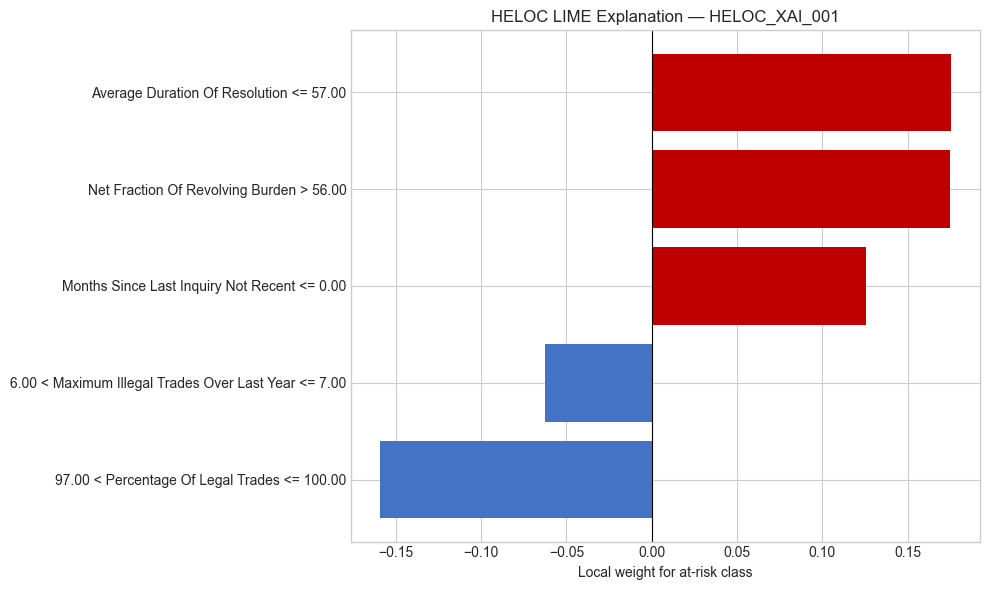

In [5]:
plain_rows=[]
for case in xai_cases.itertuples(index=False):
    factors=top_factors.loc[top_factors.case_id.eq(case.case_id)].sort_values("rank").head(2); statements=[]
    for factor in factors.itertuples(index=False):
        verb="increased" if factor.lime_weight>0 else "reduced"
        if str(factor.display_value).startswith("special code"):
            statements.append(f"{factor.display_feature}: {factor.display_value} {verb} the local at-risk prediction")
        else: statements.append(f"{factor.display_rule} {verb} the local at-risk prediction")
    plain_rows.append({"case_id":case.case_id,"explanation":"; while ".join(statements)+". These are local model associations, not causal effects."})
plain_english=pd.DataFrame(plain_rows); plain_english.to_csv(ARTIFACT_DIR/"lime_plain_english.csv",index=False); display(plain_english.head())

representative_id="HELOC_XAI_001"; representative=top_factors.loc[top_factors.case_id.eq(representative_id)].sort_values("lime_weight")
fig,ax=plt.subplots(figsize=(10,6)); ax.barh(representative.display_rule,representative.lime_weight,color=np.where(representative.lime_weight>=0,"#C00000","#4472C4")); ax.axvline(0,color="black",linewidth=.8)
ax.set(title=f"HELOC LIME Explanation — {representative_id}",xlabel="Local weight for at-risk class",ylabel="")
plt.tight_layout(); plt.savefig(PLOT_DIR/"heloc_lime_representative_explanation.png",dpi=300); plt.show()

## 6. Compactness and local fidelity

Compactness is calculated among the five reported factors. Fidelity metrics are retained without tuning after inspection.

In [6]:
sparsity_rows=[]
for case in xai_cases.itertuples(index=False):
    weights=np.sort(top_factors.loc[top_factors.case_id.eq(case.case_id),"lime_weight"].abs().to_numpy())[::-1]; total=weights.sum(); cumulative=np.cumsum(weights)/total
    sparsity_rows.append({"case_id":case.case_id,"number_of_reported_features":len(weights),"absolute_weight_sum":total,
    "features_for_50_percent":int(np.searchsorted(cumulative,.5)+1),"features_for_80_percent":int(np.searchsorted(cumulative,.8)+1)})
sparsity=pd.DataFrame(sparsity_rows); sparsity.to_csv(ARTIFACT_DIR/"lime_sparsity_metrics.csv",index=False)
fidelity=local_explanations.groupby(["case_id","row_index","predicted_probability"],as_index=False).agg(lime_local_prediction=("lime_local_prediction","first"),local_fidelity_r2=("local_fidelity_r2","first"))
fidelity["absolute_local_prediction_error"]=(fidelity.predicted_probability-fidelity.lime_local_prediction).abs(); fidelity.to_csv(ARTIFACT_DIR/"lime_local_fidelity.csv",index=False)
display(sparsity[["features_for_50_percent","features_for_80_percent"]].describe().loc[["mean","50%","min","max"]])
display(fidelity[["local_fidelity_r2","absolute_local_prediction_error"]].describe().loc[["count","mean","50%","min","max"]])

,features_for_50_percent,features_for_80_percent
mean,2.25,4.0
50%,2.00,4.0
min,2.00,4.0
max,3.00,4.0


,local_fidelity_r2,absolute_local_prediction_error
count,20.000000,20.000000
mean,0.416343,0.104207
50%,0.429768,0.063888
min,0.160894,0.001754
max,0.573275,0.297248


## 7. Same-seed reproducibility

Two fresh explainers use identical seeds and configuration for each of the first five cases. This is a same-seed reproducibility diagnostic, not a broader robustness claim.

In [7]:
stability_rows=[]
for case in xai_cases.head(5).itertuples(index=False):
    instance=X_test_raw.loc[case.row_index,selected_features].to_numpy(dtype=float); runs=[]
    for _ in range(2):
        repeated=make_explainer().explain_instance(instance,lime_predict_proba,labels=(1,),num_features=NUM_FEATURES,num_samples=NUM_SAMPLES)
        pairs=[(identify_feature(rule),float(weight)) for rule,weight in repeated.as_list(label=1)]; runs.append(pairs)
    features_a=[x[0] for x in runs[0]]; features_b=[x[0] for x in runs[1]]; weights_a=np.asarray([x[1] for x in runs[0]]); weights_b=np.asarray([x[1] for x in runs[1]])
    same_order=features_a==features_b; same_set=set(features_a)==set(features_b); max_difference=float(np.max(np.abs(weights_a-weights_b))) if same_order else np.nan
    stability_rows.append({"case_id":case.case_id,"diagnostic":"same-seed reproducibility / preliminary stability diagnostic","same_top_5_features":same_set,
    "same_feature_order":same_order,"maximum_absolute_weight_difference":max_difference,"exact_reproduction":bool(same_order and np.array_equal(weights_a,weights_b))})
stability=pd.DataFrame(stability_rows); stability.to_csv(ARTIFACT_DIR/"lime_preliminary_stability.csv",index=False); display(stability)

,case_id,diagnostic,same_top_5_features,same_feature_order,maximum_absolute_weight_difference,exact_reproduction
0,HELOC_XAI_001,same-seed reproducibility / preliminary stabil...,True,True,0.0,True
1,HELOC_XAI_002,same-seed reproducibility / preliminary stabil...,True,True,0.0,True
2,HELOC_XAI_003,same-seed reproducibility / preliminary stabil...,True,True,0.0,True
3,HELOC_XAI_004,same-seed reproducibility / preliminary stabil...,True,True,0.0,True
4,HELOC_XAI_005,same-seed reproducibility / preliminary stabil...,True,True,0.0,True


## 8. Preliminary intervention-based sensitivity

The highest-ranked ordinary-valued LIME feature is replaced with its valid training median. The result measures frozen-model sensitivity, not causality.

In [8]:
training_medians={feature:float(X_train_raw.loc[~X_train_raw[feature].isin(SPECIAL_CODES),feature].median()) for feature in selected_features}
faithfulness_rows=[]
for case in xai_cases.head(5).itertuples(index=False):
    factors=top_factors.loc[top_factors.case_id.eq(case.case_id)].sort_values("rank"); top_feature=factors.iloc[0].original_feature; intervened=replacement=None
    for factor in factors.itertuples(index=False):
        feature=factor.original_feature; original=float(X_test_raw.loc[case.row_index,feature])
        if original in SPECIAL_CODES: continue
        candidate=training_medians[feature]
        if not np.isclose(original,candidate): intervened,replacement=feature,candidate; break
    assert intervened is not None
    changed=X_test_raw.loc[[case.row_index],selected_features].copy(); original=float(changed.iloc[0][intervened]); changed.loc[case.row_index,intervened]=replacement
    changed_probability=float(lime_predict_proba(changed.to_numpy())[:,1][0])
    faithfulness_rows.append({"case_id":case.case_id,"top_lime_feature":top_feature,"intervened_feature":intervened,"original_feature_value":original,
    "replacement_value":replacement,"feature_actually_changed":True,"faithfulness_test_status":"completed","original_probability":float(case.predicted_probability),
    "intervened_probability":changed_probability,"absolute_score_change":abs(changed_probability-float(case.predicted_probability))})
faithfulness=pd.DataFrame(faithfulness_rows); faithfulness.to_csv(ARTIFACT_DIR/"lime_preliminary_faithfulness.csv",index=False); display(faithfulness)

,case_id,top_lime_feature,intervened_feature,original_feature_value,replacement_value,feature_actually_changed,faithfulness_test_status,original_probability,intervened_probability,absolute_score_change
0,HELOC_XAI_001,average_duration_of_resolution,average_duration_of_resolution,25.0,76.0,True,completed,0.948322,0.870650,0.077672
1,HELOC_XAI_002,net_fraction_of_revolving_burden,net_fraction_of_revolving_burden,83.0,30.0,True,completed,0.945186,0.919363,0.025823
2,HELOC_XAI_003,percentage_of_legal_trades,percentage_of_legal_trades,83.0,97.0,True,completed,0.944068,0.931091,0.012977
3,HELOC_XAI_004,average_duration_of_resolution,average_duration_of_resolution,15.0,76.0,True,completed,0.941455,0.822812,0.118644
4,HELOC_XAI_005,net_fraction_of_revolving_burden,net_fraction_of_revolving_burden,90.0,30.0,True,completed,0.941175,0.942817,0.001642


## 9. SHAP–LIME provenance check

The first five saved results are compared without forcing agreement or copying interventions between methods.

In [9]:
shap_top=pd.read_csv(paths["shap_top"]); shap_faithfulness=pd.read_csv(paths["shap_faithfulness"])
provenance_check=(shap_top.loc[shap_top["rank"].eq(1),["case_id","original_feature"]].rename(columns={"original_feature":"top_shap_feature"})
.merge(top_factors.loc[top_factors["rank"].eq(1),["case_id","original_feature"]].rename(columns={"original_feature":"top_lime_feature"}),on="case_id")
.merge(shap_faithfulness[["case_id","intervened_feature"]].rename(columns={"intervened_feature":"shap_intervened_feature"}),on="case_id")
.merge(faithfulness[["case_id","intervened_feature"]].rename(columns={"intervened_feature":"lime_intervened_feature"}),on="case_id"))
provenance_check=provenance_check.loc[provenance_check.case_id.isin(xai_cases.head(5).case_id)].copy()
provenance_check["same_top_feature"]=provenance_check.top_shap_feature.eq(provenance_check.top_lime_feature)
provenance_check["same_intervened_feature"]=provenance_check.shap_intervened_feature.eq(provenance_check.lime_intervened_feature)
provenance_check.to_csv(ARTIFACT_DIR/"stage06_shap_lime_provenance_check.csv",index=False); display(provenance_check)

,case_id,top_shap_feature,top_lime_feature,shap_intervened_feature,lime_intervened_feature,same_top_feature,same_intervened_feature
0,HELOC_XAI_001,average_duration_of_resolution,average_duration_of_resolution,average_duration_of_resolution,average_duration_of_resolution,True,True
1,HELOC_XAI_002,average_duration_of_resolution,net_fraction_of_revolving_burden,average_duration_of_resolution,net_fraction_of_revolving_burden,False,False
2,HELOC_XAI_003,average_duration_of_resolution,percentage_of_legal_trades,average_duration_of_resolution,percentage_of_legal_trades,False,False
3,HELOC_XAI_004,average_duration_of_resolution,average_duration_of_resolution,average_duration_of_resolution,average_duration_of_resolution,True,True
4,HELOC_XAI_005,average_duration_of_resolution,net_fraction_of_revolving_burden,average_duration_of_resolution,net_fraction_of_revolving_burden,False,False


## 10. Metadata and final checks

The metadata records the fixed configuration and frozen-state assurances. SHAP artifacts are loaded only for provenance comparison and are not regenerated.

In [10]:
metadata={"dataset":"mstz/heloc risk configuration","model_path":str(paths["model"].relative_to(PROJECT_ROOT)),"preprocessor_path":str(paths["preprocessor"].relative_to(PROJECT_ROOT)),
"training_background_rows":len(X_train_raw),"fixed_xai_case_count":len(xai_cases),"original_feature_count":len(selected_features),"num_samples":NUM_SAMPLES,"num_features":NUM_FEATURES,
"random_state":RANDOM_STATE,"wrapper_maximum_probability_difference":wrapper_max_difference,"representative_case":representative_id,
"stability_cases_tested":len(stability),"faithfulness_cases_tested":len(faithfulness),"special_code_semantics_verified":False,"model_retrained":False,"preprocessor_refitted":False}
(ARTIFACT_DIR/"lime_metadata.json").write_text(json.dumps(metadata,indent=2),encoding="utf-8")
assert len(X_train_raw)==7896 and len(X_test_raw)==1974 and wrapper_max_difference<=1e-12
assert len(xai_cases)==20 and len(local_explanations)==len(top_factors)==100 and len(plain_english)==len(sparsity)==len(fidelity)==20
assert len(stability)==len(faithfulness)==5 and faithfulness.feature_actually_changed.all()
print("Frozen model loaded: True"); print("Exact train rows reconstructed: 7896"); print("Exact test rows reconstructed: 1974"); print("Frozen predictions reproduced: True")
print("LIME wrapper probability difference:",wrapper_max_difference); print("Fixed XAI cases: 20"); print("Local explanation rows: 100"); print("Top-factor rows: 100")
print("Plain-English rows: 20"); print("Sparsity rows: 20"); print("Stability rows: 5"); print("Faithfulness rows: 5"); print("Local-fidelity rows: 20")
print("Model retrained: False"); print("Preprocessor refitted: False"); print("New split created: False"); print("SHAP rerun: False"); print("DiCE executed: False")

Frozen model loaded: True
Exact train rows reconstructed: 7896
Exact test rows reconstructed: 1974
Frozen predictions reproduced: True
LIME wrapper probability difference: 0.0
Fixed XAI cases: 20
Local explanation rows: 100
Top-factor rows: 100
Plain-English rows: 20
Sparsity rows: 20
Stability rows: 5
Faithfulness rows: 5
Local-fidelity rows: 20
Model retrained: False
Preprocessor refitted: False
New split created: False
SHAP rerun: False
DiCE executed: False


## 11. Stage 07 hand-off

The LIME artifacts are frozen for review. DiCE and the cross-method evaluation are not started here.